# Liver Disease Prediction
In this machine learning project, we will predict whether a person is suffering from Liver Disease or not.

### Importing the necessary libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

### Loading the Data set

In [2]:
df = pd.read_csv("indian_liver_patient.csv")
df.head()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
0,65.0,Female,0.7,0.1,187.0,16.0,18.0,6.8,3.3,0.9,1
1,62.0,Male,10.9,5.5,699.0,64.0,100.0,7.5,3.2,0.7,1
2,62.0,Male,7.3,4.1,490.0,60.0,68.0,7.0,3.3,0.9,1
3,58.0,Male,1.0,0.4,182.0,14.0,20.0,6.8,3.4,1.0,1
4,72.0,Male,3.9,2.0,195.0,27.0,59.0,7.3,2.4,0.4,1


In [3]:
# Lets see the shape of the dataset

df.shape

(30691, 11)

### Exploratory Data Analysis (EDA)

In [4]:
# Lets see some informations about the data

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30691 entries, 0 to 30690
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         30691 non-null  float64
 1   Gender                      30691 non-null  object 
 2   Total_Bilirubin             30691 non-null  float64
 3   Direct_Bilirubin            30691 non-null  float64
 4   Alkaline_Phosphotase        30691 non-null  float64
 5   Alamine_Aminotransferase    30691 non-null  float64
 6   Aspartate_Aminotransferase  30691 non-null  float64
 7   Total_Protiens              30691 non-null  float64
 8   Albumin                     30691 non-null  float64
 9   Albumin_and_Globulin_Ratio  30691 non-null  float64
 10  Dataset                     30691 non-null  int64  
dtypes: float64(9), int64(1), object(1)
memory usage: 2.6+ MB


In [5]:
# Lets see the description of the dataset

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,30691.0,44.107204,15.980523,4.0,32.0,45.0,55.0,90.0
Total_Bilirubin,30691.0,3.370917,6.189379,0.4,0.8,1.0,2.8,75.0
Direct_Bilirubin,30691.0,1.527409,2.843283,0.1,0.2,0.3,1.4,19.7
Alkaline_Phosphotase,30691.0,289.070943,235.424918,63.0,176.0,214.0,295.5,2110.0
Alamine_Aminotransferase,30691.0,81.482193,180.556126,10.0,23.0,36.0,64.0,2000.0
Aspartate_Aminotransferase,30691.0,111.461699,278.730382,10.0,26.0,43.0,90.0,4929.0
Total_Protiens,30691.0,6.480522,1.073793,2.7,5.8,6.5,7.2,9.6
Albumin,30691.0,3.129663,0.785923,0.9,2.6,3.1,3.7,5.5
Albumin_and_Globulin_Ratio,30691.0,0.943941,0.319762,0.3,0.7,0.9,1.1,2.8
Dataset,30691.0,1.285882,0.451841,1.0,1.0,1.0,2.0,2.0


In [6]:
# Lets check for null values

df.isnull().sum()

Age                           0
Gender                        0
Total_Bilirubin               0
Direct_Bilirubin              0
Alkaline_Phosphotase          0
Alamine_Aminotransferase      0
Aspartate_Aminotransferase    0
Total_Protiens                0
Albumin                       0
Albumin_and_Globulin_Ratio    0
Dataset                       0
dtype: int64

We can see 4 null values in the feature Albumin_and_Globulin_Ratio

In [7]:
df = df.dropna()

The number of patients diagnosed with liver disease: 21917
The number of patients not diagnosed with liver disease: 8774


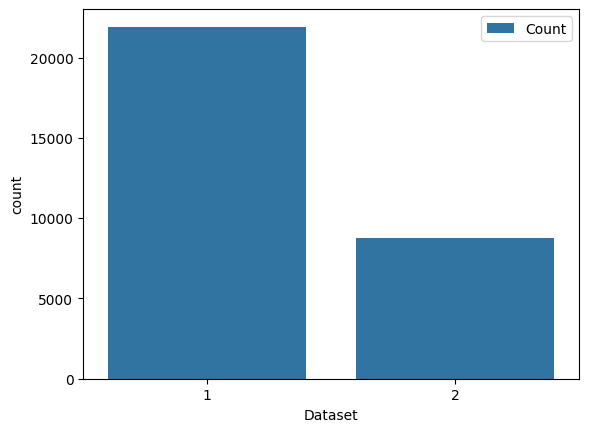

In [8]:
# Countplot to see the number of unique values in the target column("Dataset")

sns.countplot(data = df, x = "Dataset", label = "Count")
LD, NLD = df["Dataset"].value_counts()
print("The number of patients diagnosed with liver disease: {}".format(LD))
print("The number of patients not diagnosed with liver disease: {}".format(NLD))

We can see that the target ("Dataset") column is balanced.

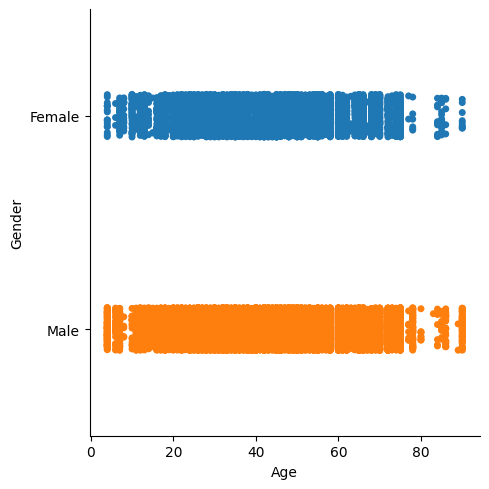

In [9]:
# Factor plot

sns.catplot(x="Age", y="Gender", hue="Gender", data=df)

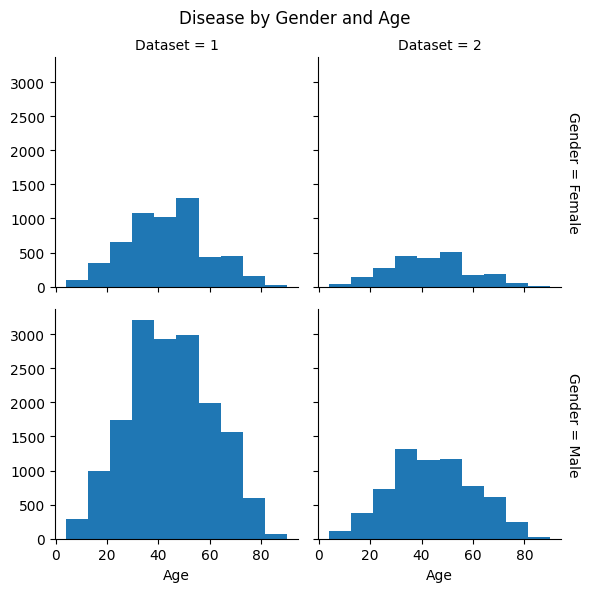

In [10]:
# Histogram

g = sns.FacetGrid(df, col="Dataset", row="Gender", margin_titles=True)
g.map(plt.hist, "Age")
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Disease by Gender and Age');

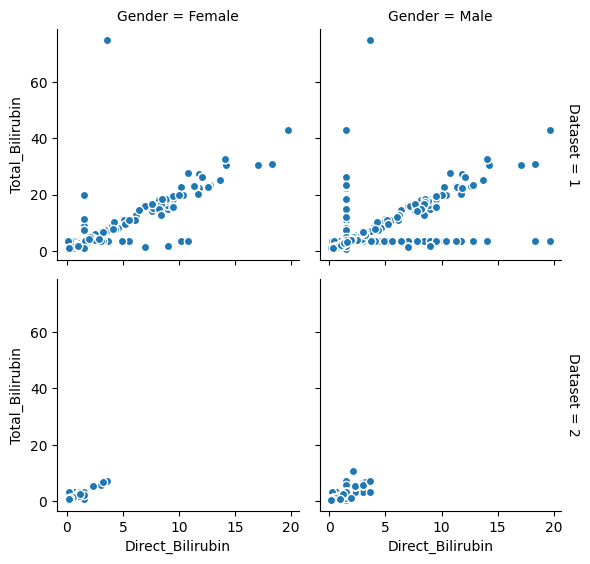

In [11]:
# Scatterplot

g = sns.FacetGrid(df, col="Gender", row="Dataset", margin_titles=True)
g.map(plt.scatter,"Direct_Bilirubin", "Total_Bilirubin", edgecolor="w")
plt.subplots_adjust(top=0.9)

In [12]:
# Independent and Dependent feature for basic data analysis

x = df.drop(['Gender','Dataset'], axis=1)
Y = df['Dataset'] # 1 for liver disease; 2 for no liver disease

In [13]:
# Drop non-numeric columns
numeric_df = df.select_dtypes(include=[float, int])

# Calculate correlation
correlation_matrix = numeric_df.corr()
print(correlation_matrix)


                                 Age  Total_Bilirubin  Direct_Bilirubin  \
Age                         1.000000        -0.001503         -0.001520   
Total_Bilirubin            -0.001503         1.000000          0.877685   
Direct_Bilirubin           -0.001520         0.877685          1.000000   
Alkaline_Phosphotase       -0.000757         0.193911          0.217421   
Alamine_Aminotransferase    0.000669         0.203659          0.219834   
Aspartate_Aminotransferase  0.006051         0.238265          0.254211   
Total_Protiens             -0.007889         0.001168          0.006371   
Albumin                    -0.015054        -0.218972         -0.225655   
Albumin_and_Globulin_Ratio -0.017572        -0.195698         -0.187568   
Dataset                    -0.004759        -0.222447         -0.247084   

                            Alkaline_Phosphotase  Alamine_Aminotransferase  \
Age                                    -0.000757                  0.000669   
Total_Bilirubin   

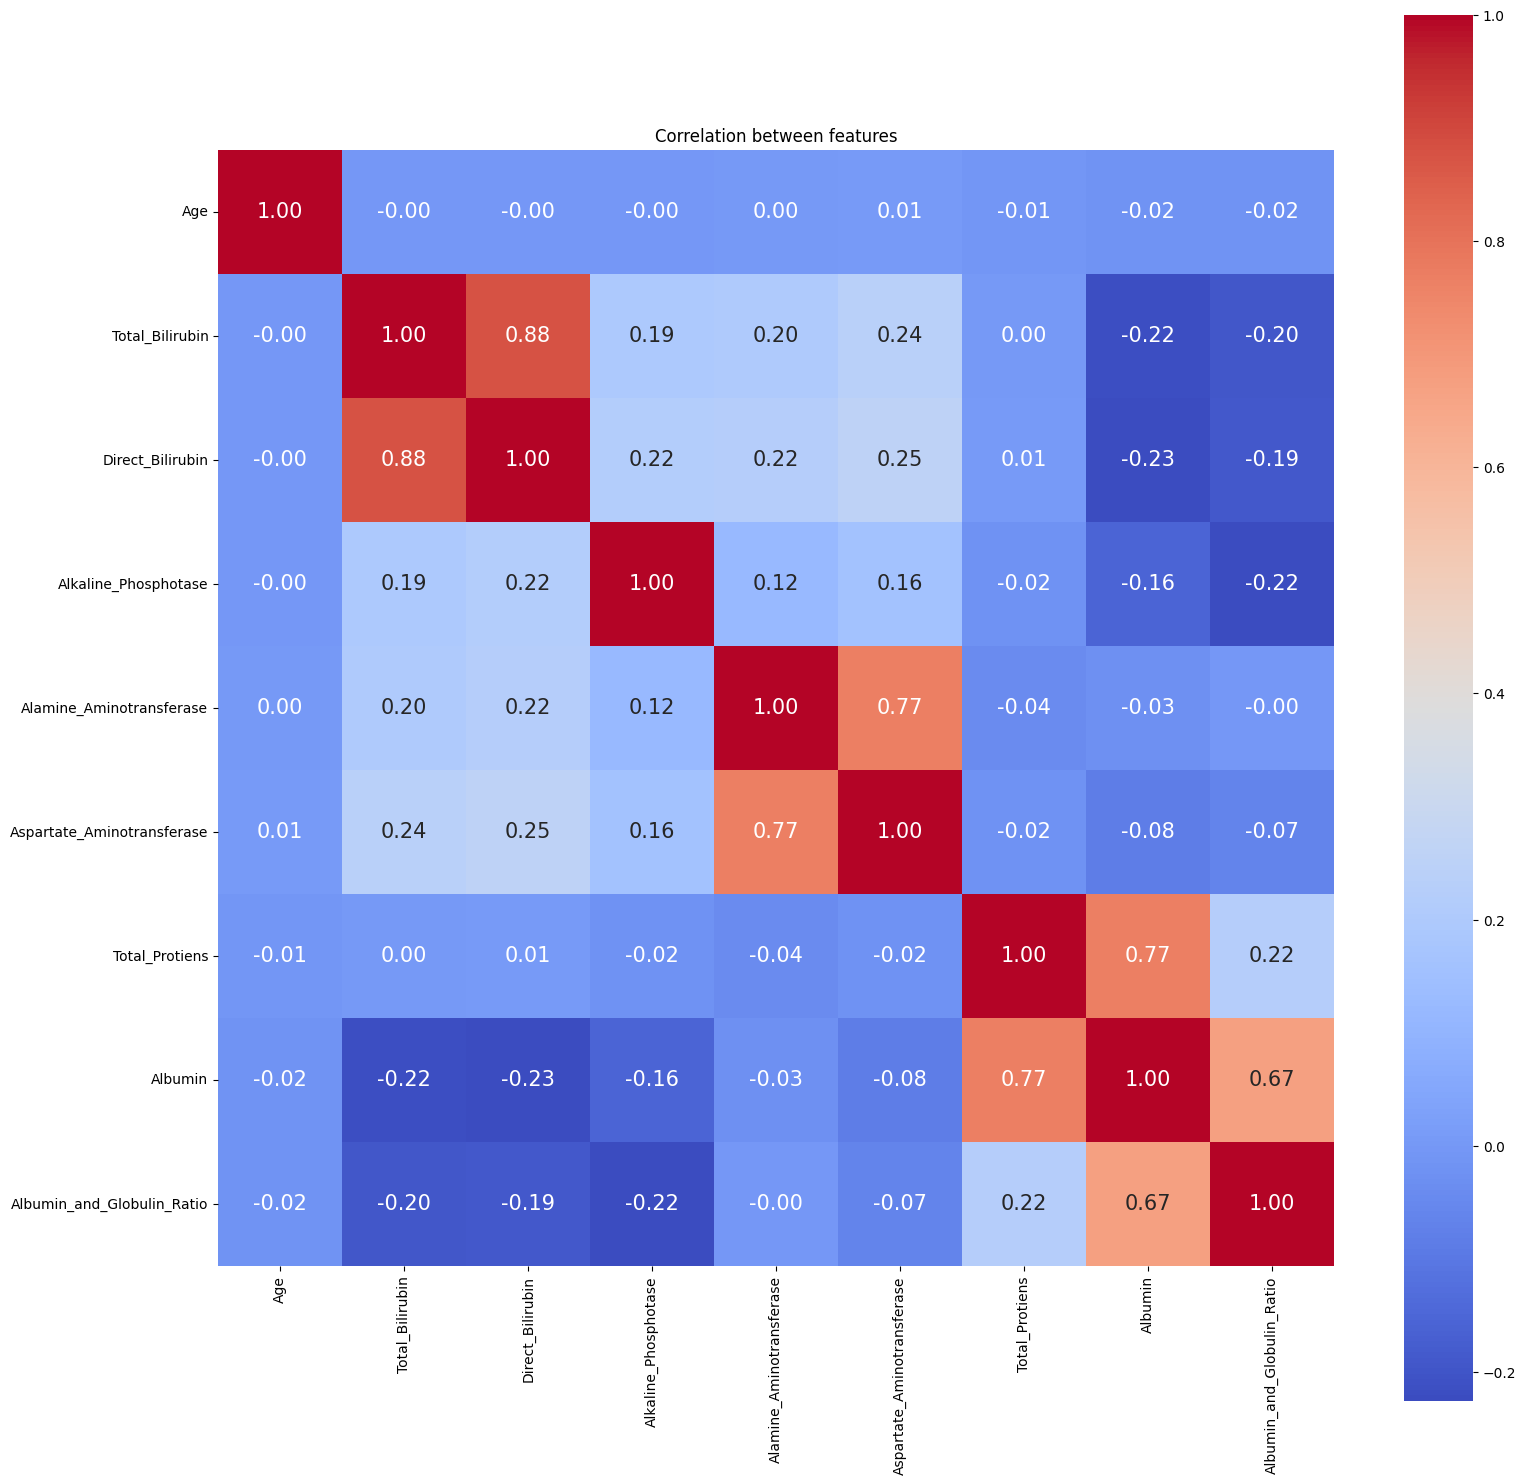

In [14]:
# Heatmap showing the correlation between the independent features

liver_corr = x.corr()
plt.figure(figsize=(18,18))
sns.heatmap(liver_corr, cbar = True,  square = True, annot=True, fmt= '.2f',annot_kws={'size': 15},
           cmap= 'coolwarm')
plt.title('Correlation between features');

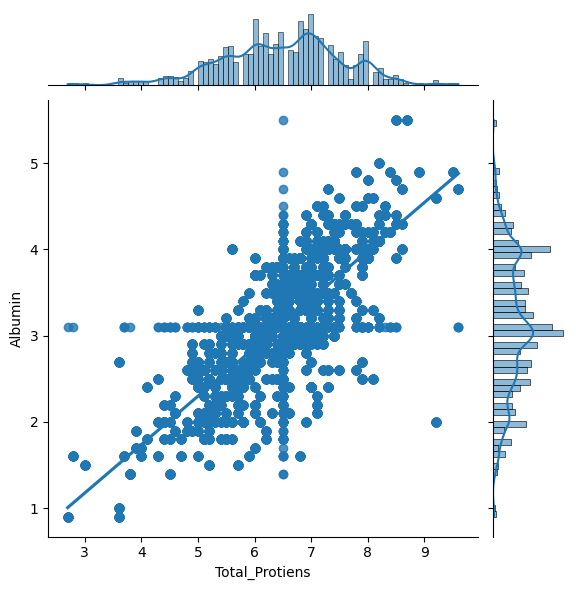

In [15]:
#Jointplot

sns.jointplot(x="Total_Protiens", y="Albumin", data=df, kind="reg")

### Feature Engineering

In [16]:
# Handling the missing values of the feature Albumin_and_Globulin_Ratio

df["Albumin_and_Globulin_Ratio"] = df.Albumin_and_Globulin_Ratio.fillna(df['Albumin_and_Globulin_Ratio'].mean())

In [17]:
df['Gender'] = df['Gender'].str.strip()
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})

In [18]:
df = df.dropna(subset=['Gender'])

In [19]:
print(df['Gender'].unique())

[0 1]


In [20]:
# Label Encoding for the Gender feature

#df['Gender'] = df['Gender'].apply(lambda x:1 if x == 'Male' else 0)

In [21]:
# Filling nan values(if any) with 0.94 (from domain knowledge)

df = df.fillna(0.94)

In [22]:
X = df[['Age', 'Gender', 'Total_Bilirubin', 'Direct_Bilirubin',
        'Alkaline_Phosphotase', 'Alamine_Aminotransferase',
        'Aspartate_Aminotransferase', 'Total_Protiens',
        'Albumin', 'Albumin_and_Globulin_Ratio']]

y = df['Dataset']  # or whatever your target column is


In [23]:
# Train test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 123)

In [24]:
# Lets see the shape of the train and test datasets

print('Shape training set: X:{}, y:{}'.format(X_train.shape, y_train.shape))
print('Shape test set: X:{}, y:{}'.format(X_test.shape, y_test.shape))

Shape training set: X:(21483, 10), y:(21483,)
Shape test set: X:(9208, 10), y:(9208,)


### Model Building

In [25]:
from sklearn.neighbors import KNeighborsClassifier

In [26]:
rf = KNeighborsClassifier()
rf.fit(X_train, y_train)

KNeighborsClassifier()

In [27]:
# Prediction

pred = rf.predict(X_test)

In [28]:
# Validation

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print(accuracy_score(pred, y_test))
print(confusion_matrix(pred, y_test))
print(classification_report(pred, y_test))

0.9605777584708949
[[6408  186]
 [ 177 2437]]
              precision    recall  f1-score   support

           1       0.97      0.97      0.97      6594
           2       0.93      0.93      0.93      2614

    accuracy                           0.96      9208
   macro avg       0.95      0.95      0.95      9208
weighted avg       0.96      0.96      0.96      9208



### Hyperparameter Optimization

In [29]:
# Number of trees in random forest
n_estimators=[int(x) for x in np.linspace(start=200,stop=2000,num=10)]

# Number of features to consider at every split
max_features=['auto','sqrt', 'log2']

# Maximum number of levels in tree
max_depth=[int(x) for x in np.linspace(10,1000,10)]

# Minimum number of samples required to split a node
min_samples_split=[2,5,10,14]

# Minimum number of samples required at each leaf node
min_samples_leaf=[1,2,4,6,8]

# Create the random grid
random_grid={'n_estimators':n_estimators,
            'max_features':max_features,
             'max_depth':max_depth,
             'min_samples_split':min_samples_split,
             'min_samples_leaf':min_samples_leaf,
             'criterion':['entropy','gini']}
print(random_grid)

{'n_estimators': [200, 400, 600, 800, 1000, 1200, 1400, 1600, 1800, 2000], 'max_features': ['auto', 'sqrt', 'log2'], 'max_depth': [10, 120, 230, 340, 450, 560, 670, 780, 890, 1000], 'min_samples_split': [2, 5, 10, 14], 'min_samples_leaf': [1, 2, 4, 6, 8], 'criterion': ['entropy', 'gini']}


In [38]:
from sklearn.model_selection import RandomizedSearchCV


knn = KNeighborsClassifier()
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

knn_randomCV = RandomizedSearchCV(
    estimator=knn,
    param_distributions=param_grid,
    n_iter=50,            
    cv=100,                
    verbose=2,
    random_state=100,
    n_jobs=-1             
)

knn_randomCV.fit(X_train, y_train)

y_pred = knn_randomCV.predict(X_test)

c:\Users\Ragha\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 42 is smaller than n_iter=50. Running 42 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 100 folds for each of 42 candidates, totalling 4200 fits


In [39]:
# Getting the best parameters

knn_randomCV.best_params_

{'weights': 'distance', 'n_neighbors': 5, 'metric': 'manhattan'}

In [40]:
# Getting the best estimator

knn_randomCV.best_estimator_

KNeighborsClassifier(metric='manhattan', weights='distance')

In [41]:
# Initializing the model with the best parameters

knn = KNeighborsClassifier(
    n_neighbors=5,       
    weights='uniform',   
    metric='euclidean',  
    algorithm='auto',    
    leaf_size=30,        
    p=2                  
)

In [42]:
# Model Fitting with best parameters

knn.fit(X_train, y_train)

KNeighborsClassifier(metric='euclidean')

In [43]:
# Prediction

y_pred = knn.predict(X_test)

In [44]:
# Validation

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print(accuracy_score(y_pred, y_test))
print(confusion_matrix(y_pred, y_test))
print(classification_report(y_pred, y_test))

0.9605777584708949
[[6408  186]
 [ 177 2437]]
              precision    recall  f1-score   support

           1       0.97      0.97      0.97      6594
           2       0.93      0.93      0.93      2614

    accuracy                           0.96      9208
   macro avg       0.95      0.95      0.95      9208
weighted avg       0.96      0.96      0.96      9208



### Saving the model for future use

In [45]:
import pickle

with open('liver_model.pkl', 'wb') as file:
    pickle.dump(knn, file)
